<a href="https://colab.research.google.com/github/gunasekaran01/apexplanet_task2/blob/main/apexplanet_task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install openpyxl pandasql

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=5fb9a5d85b5bff079e36520d822eefa0d8d03039a55d6ac57193abf741dd6938
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
from pandasql import sqldf

plt.style.use('ggplot')

In [3]:
from google.colab import files

uploaded = files.upload()

Saving ApexPlanet_DataAnalytics_Dataset.xlsx to ApexPlanet_DataAnalytics_Dataset.xlsx


In [4]:
df = pd.read_excel("ApexPlanet_DataAnalytics_Dataset.xlsx")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [5]:
print(df.info())

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values")
print(df.isnull().sum())
df.describe(include='all')
df["Age"] = df["Age"].fillna(df["Age"].median())

df["City"] = df["City"].fillna("Unknown")

df["Order_Date"] = pd.to_datetime(df["Order_Date"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Customer_ID    1000 non-null   object 
 3   Customer_Name  1000 non-null   object 
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   object 
 6   City           987 non-null    object 
 7   Product        1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 93.9+ KB
None

Shape:
(1000, 12)

Columns:
Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age',
       'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Total_Sales'],
      dtype=

In [6]:
df["Month"] = df["Order_Date"].dt.month_name()

df["Year"] = df["Order_Date"].dt.year
print("Total Revenue:",df["Total_Sales"].sum())

print("Average Revenue:",df["Total_Sales"].mean())

print("Maximum Sale:",df["Total_Sales"].max())

print("Minimum Sale:",df["Total_Sales"].min())
top_products = df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False)

top_products.head(10)

Total Revenue: 139399439.65
Average Revenue: 139399.43965000001
Maximum Sale: 493677.5
Minimum Sale: 437.34


,Total_Sales
Product,
Laptop,25443008.51
Mobile,25335573.19
Book,25031689.40
Rice,22231711.28
Chair,21521561.48
Shoes,19835895.79


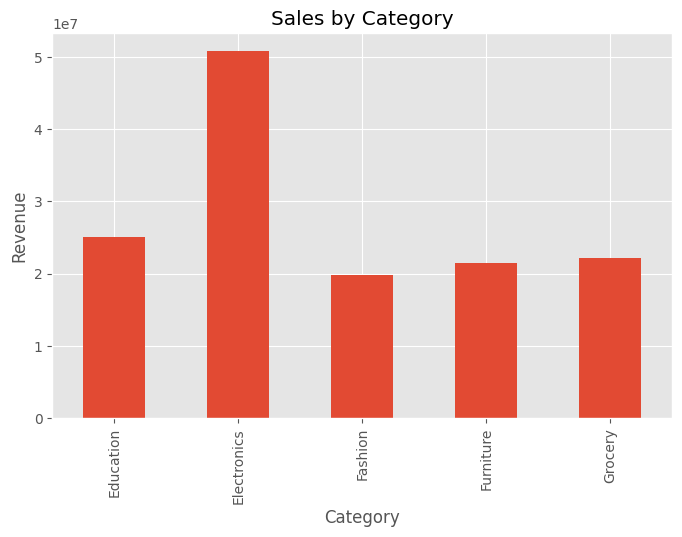

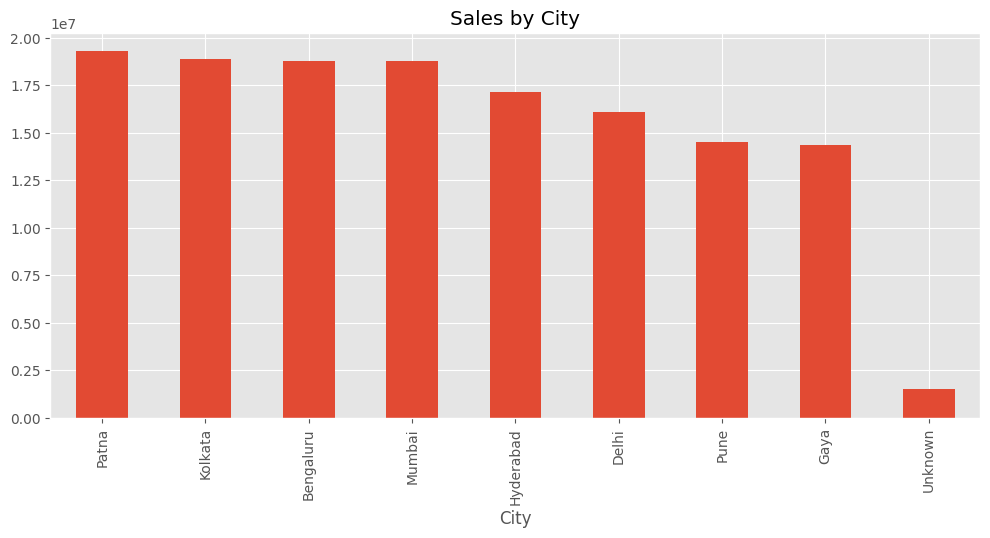

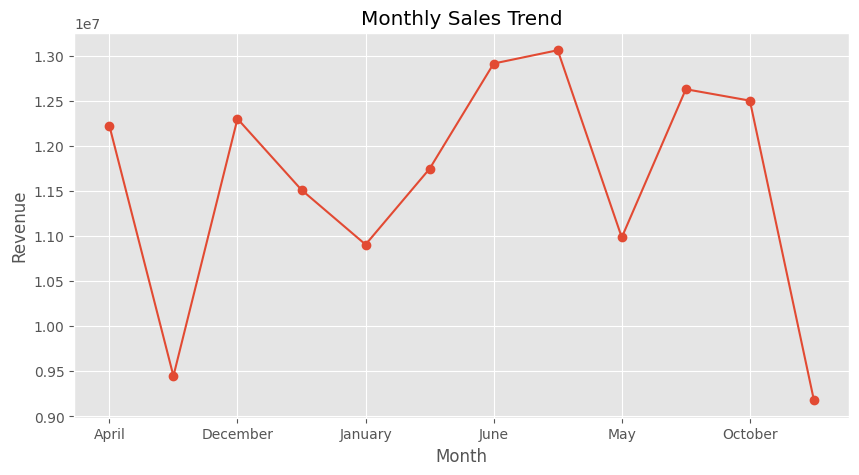

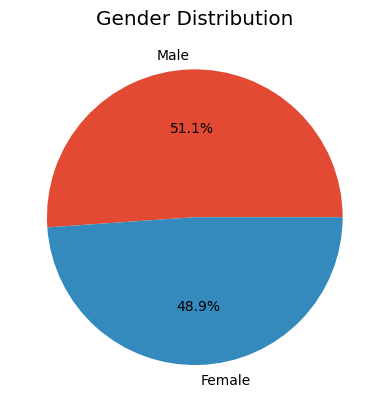

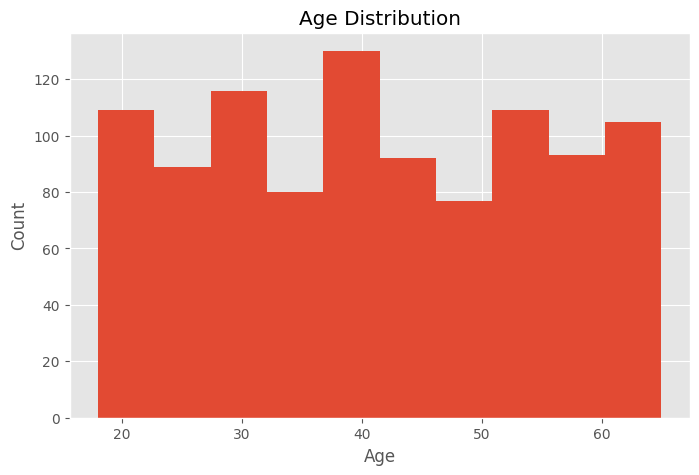

In [7]:
category_sales = df.groupby("Category")["Total_Sales"].sum()

category_sales.plot(kind="bar",figsize=(8,5))

plt.title("Sales by Category")

plt.ylabel("Revenue")

plt.show()

city_sales = df.groupby("City")["Total_Sales"].sum().sort_values(ascending=False)

city_sales.plot(kind="bar",figsize=(12,5))

plt.title("Sales by City")

plt.show()

monthly_sales=df.groupby("Month")["Total_Sales"].sum()

monthly_sales.plot(marker="o",figsize=(10,5))

plt.title("Monthly Sales Trend")

plt.ylabel("Revenue")

plt.show()

gender=df["Gender"].value_counts()

gender.plot(kind="pie",autopct="%1.1f%%")

plt.ylabel("")

plt.title("Gender Distribution")

plt.show()

plt.figure(figsize=(8,5))

plt.hist(df["Age"],bins=10)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

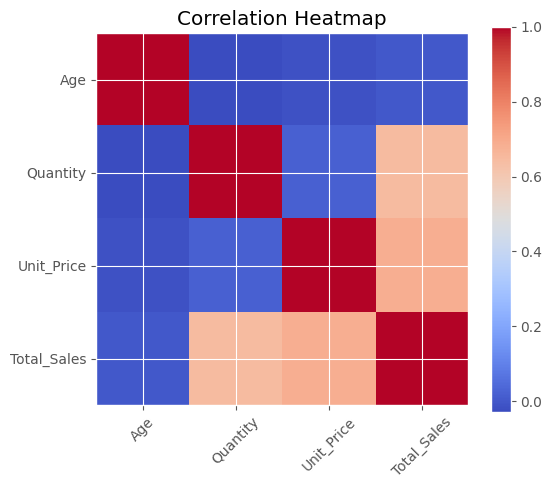

In [8]:
top_customers=df.groupby("Customer_Name")["Total_Sales"].sum()

top_customers.sort_values(ascending=False).head(10)
corr=df[["Age","Quantity","Unit_Price","Total_Sales"]].corr()

corr
plt.figure(figsize=(6,5))

plt.imshow(corr,cmap='coolwarm')

plt.xticks(range(len(corr.columns)),corr.columns,rotation=45)

plt.yticks(range(len(corr.columns)),corr.columns)

plt.colorbar()

plt.title("Correlation Heatmap")

plt.show()

In [9]:
conn=sqlite3.connect(":memory:")

df.to_sql("sales",conn,index=False,if_exists="replace")

1000

In [13]:
query="""

SELECT Product,

SUM(Total_Sales) AS Revenue

FROM sales

GROUP BY Product

ORDER BY Revenue DESC

LIMIT 5

"""

pd.read_sql(query,conn)
query="""

SELECT City,

SUM(Total_Sales) Revenue

FROM sales

GROUP BY City

ORDER BY Revenue DESC

LIMIT 5

"""

pd.read_sql(query,conn)
query="""

SELECT Category,

SUM(Total_Sales) Revenue

FROM sales

GROUP BY Category

ORDER BY Revenue DESC

"""

pd.read_sql(query,conn)
query="""

SELECT

AVG(Total_Sales) Average_Sales

FROM sales

"""

pd.read_sql(query,conn)
query="""

SELECT Customer_Name,

SUM(Total_Sales) Revenue

FROM sales

GROUP BY Customer_Name

ORDER BY Revenue DESC

LIMIT 10

"""

pd.read_sql(query,conn)
query="""

SELECT Month,

SUM(Total_Sales) Revenue

FROM sales

GROUP BY Month

"""

pd.read_sql(query,conn)
query="""

SELECT Category,

AVG(Age) Average_Age

FROM sales

GROUP BY Category

"""

pd.read_sql(query,conn)

,Category,Average_Age
0,Education,42.528090
1,Electronics,41.135593
2,Fashion,41.487179
3,Furniture,40.534591
4,Grocery,41.202614


In [11]:
df.to_csv("EDA_Cleaned_Dataset.csv",index=False)

In [12]:
from google.colab import files

files.download("EDA_Cleaned_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>